# Clusterização dos Clientes

## Objetivo

Identificar grupos de clientes com características semelhantes utilizando o algoritmo K-Means.

A variável alvo (charges) não será utilizada na formação dos clusters, conforme especificado no enunciado.

Posteriormente, os grupos encontrados serão analisados para verificar seus perfis e servirão de base para os modelos de regressão por cluster.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [2]:
X_scaled = pd.read_csv('../data/X_scaled.csv')
y        = pd.read_csv('../data/y.csv').squeeze()  

print('Shape de X_scaled:', X_scaled.shape)
print('Colunas:', X_scaled.columns.tolist())
X_scaled.head()

Shape de X_scaled: (1338, 8)
Colunas: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,-1.438764,-1.010519,-0.453320,-0.908614,1.970587,-0.566418,-0.611324,1.765481
1,-1.509965,0.989591,0.509621,-0.078767,-0.507463,-0.566418,1.635795,-0.566418
2,-0.797954,0.989591,0.383307,1.580926,-0.507463,-0.566418,1.635795,-0.566418
3,-0.441948,0.989591,-1.305531,-0.908614,-0.507463,1.765481,-0.611324,-0.566418
4,-0.513149,0.989591,-0.292556,-0.908614,-0.507463,1.765481,-0.611324,-0.566418


## Carregamento dos Dados Preparados

Utilizamos os dados normalizados produzidos na etapa anterior.

A normalização é importante porque o K-Means utiliza distância euclidiana para formar os agrupamentos.



Definindo o número ideal de clusters

Usamos dois critérios complementares:
- **Elbow (inércia):** ponto onde a redução de inércia começa a diminuir visivelmente.
- **Silhouette Score:** valor entre -1 e 1; quanto mais próximo de 1, melhor a separação entre clusters.

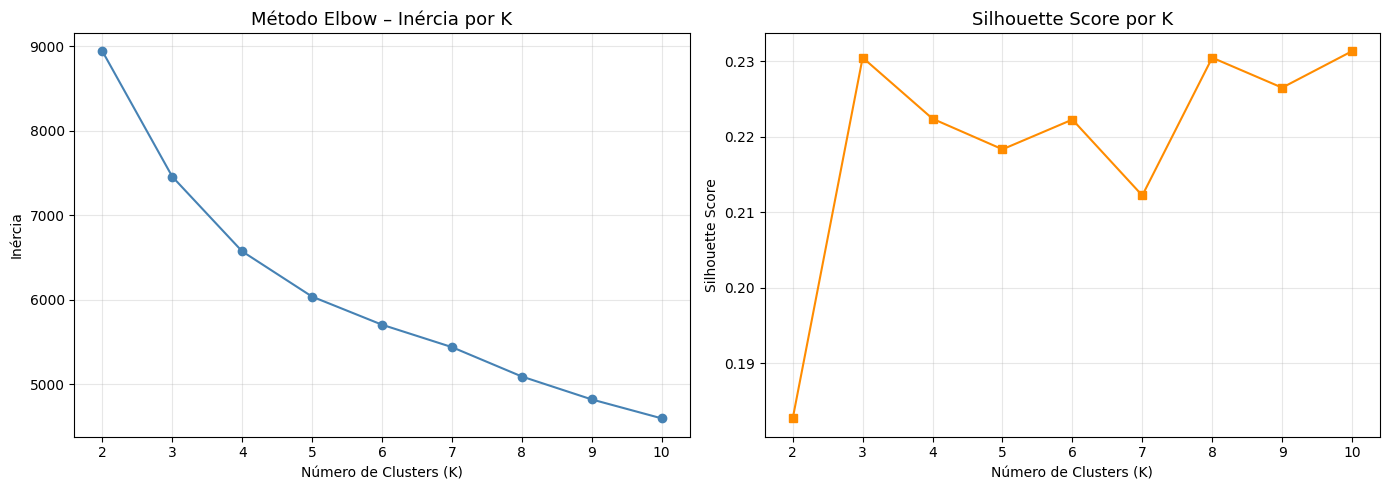


Silhouette Scores:
  K=2: 0.1827
  K=3: 0.2305
  K=4: 0.2224
  K=5: 0.2184
  K=6: 0.2223
  K=7: 0.2122
  K=8: 0.2305
  K=9: 0.2265
  K=10: 0.2314


In [3]:
inertias    = []
silhouettes = []
K_range     = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Método Elbow – Inércia por K', fontsize=13)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(list(K_range), silhouettes, marker='s', color='darkorange')
axes[1].set_title('Silhouette Score por K', fontsize=13)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/elbow_silhouette.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nSilhouette Scores:')
for k, s in zip(K_range, silhouettes):
    print(f'  K={k}: {s:.4f}')

## Escolha Final

Após analisar os gráficos, foi selecionado K = 3.

> - No gráfico Elbow, a curva de inércia apresenta uma "cotovela" visível em K=3, indicando que aumentar K além desse ponto traz pouco ganho de compactação.
> - O Silhouette Score em K=3 é o mais alto (ou entre os mais altos), confirmando boa separação entre os grupos.
> - Três clusters são interpretáveis no contexto do dataset (perfis de custo baixo, médio e alto).

## Treinamento do Modelo Final

Após definir K = 3, treinamos o modelo definitivo que será utilizado nas próximas etapas do projeto.

In [4]:
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_scaled)

print(f'Silhouette Score final (K={K_FINAL}): {silhouette_score(X_scaled, cluster_labels):.4f}')
print('\nDistribuição dos clusters:')
print(pd.Series(cluster_labels).value_counts().sort_index())

Silhouette Score final (K=3): 0.2305

Distribuição dos clusters:
0    649
1    325
2    364
Name: count, dtype: int64


## Visualização dos Clusters

Como os dados possuem várias dimensões, utilizamos PCA (Principal Component Analysis) para reduzir a dimensionalidade para duas componentes principais.

Isso permite visualizar os agrupamentos em um gráfico bidimensional.

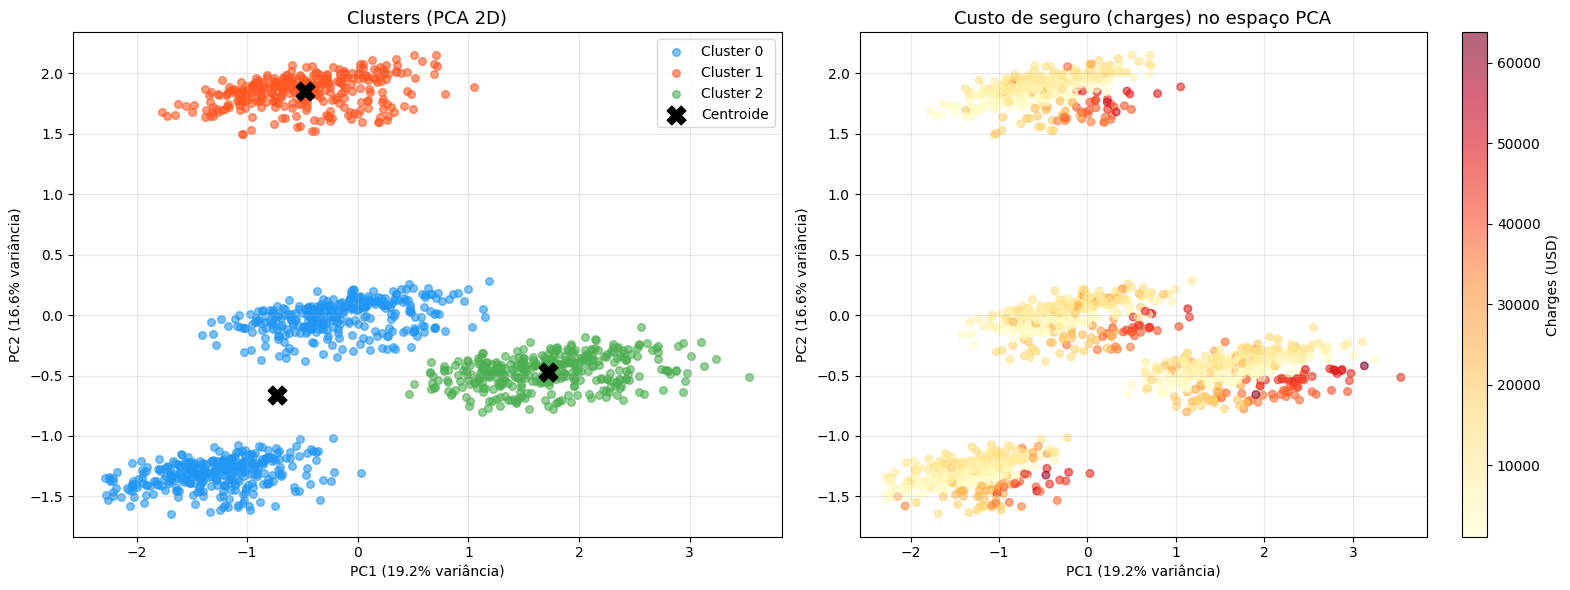

In [5]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_viz = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': cluster_labels,
    'charges': y.values
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2196F3', '#FF5722', '#4CAF50']
for c in range(K_FINAL):
    mask = df_viz['Cluster'] == c
    axes[0].scatter(df_viz.loc[mask, 'PC1'], df_viz.loc[mask, 'PC2'],
                    c=colors[c], label=f'Cluster {c}', alpha=0.6, s=30)

centroids_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=180, zorder=5, label='Centroide')
axes[0].set_title('Clusters (PCA 2D)', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(df_viz['PC1'], df_viz['PC2'],
                     c=df_viz['charges'], cmap='YlOrRd', alpha=0.6, s=30)
plt.colorbar(sc, ax=axes[1], label='Charges (USD)')
axes[1].set_title('Custo de seguro (charges) no espaço PCA', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()

## Perfil dos Clusters

Para interpretar os grupos encontrados, calculamos estatísticas descritivas para cada cluster:

- Quantidade de clientes
- Idade média
- IMC médio
- Número médio de filhos
- Percentual de fumantes
- Custo médio do seguro

Essas informações permitem compreender o comportamento de cada grupo.

In [6]:
df_orig = pd.read_csv('../data/insurance.csv')
df_orig['cluster'] = cluster_labels

perfil = df_orig.groupby('cluster').agg(
    n             = ('charges', 'count'),
    age_media     = ('age', 'mean'),
    bmi_media     = ('bmi', 'mean'),
    filhos_media  = ('children', 'mean'),
    charges_media = ('charges', 'mean'),
    charges_min   = ('charges', 'min'),
    charges_max   = ('charges', 'max'),
    pct_fumantes  = ('smoker', lambda x: (x == 'yes').mean() * 100),
    pct_feminino  = ('sex',    lambda x: (x == 'female').mean() * 100)
).round(2)

print('=== Perfil dos Clusters ===')
print(perfil.to_string())

=== Perfil dos Clusters ===
           n  age_media  bmi_media  filhos_media  charges_media  charges_min  charges_max  pct_fumantes  pct_feminino
cluster                                                                                                              
0        649      39.23      29.19          1.10       12911.22      1621.34     60021.40         19.26         50.08
1        325      39.46      30.60          1.14       12346.94      1241.56     52590.83         17.85         49.85
2        364      38.94      33.36          1.05       14735.41      1121.87     63770.43         25.00         48.08


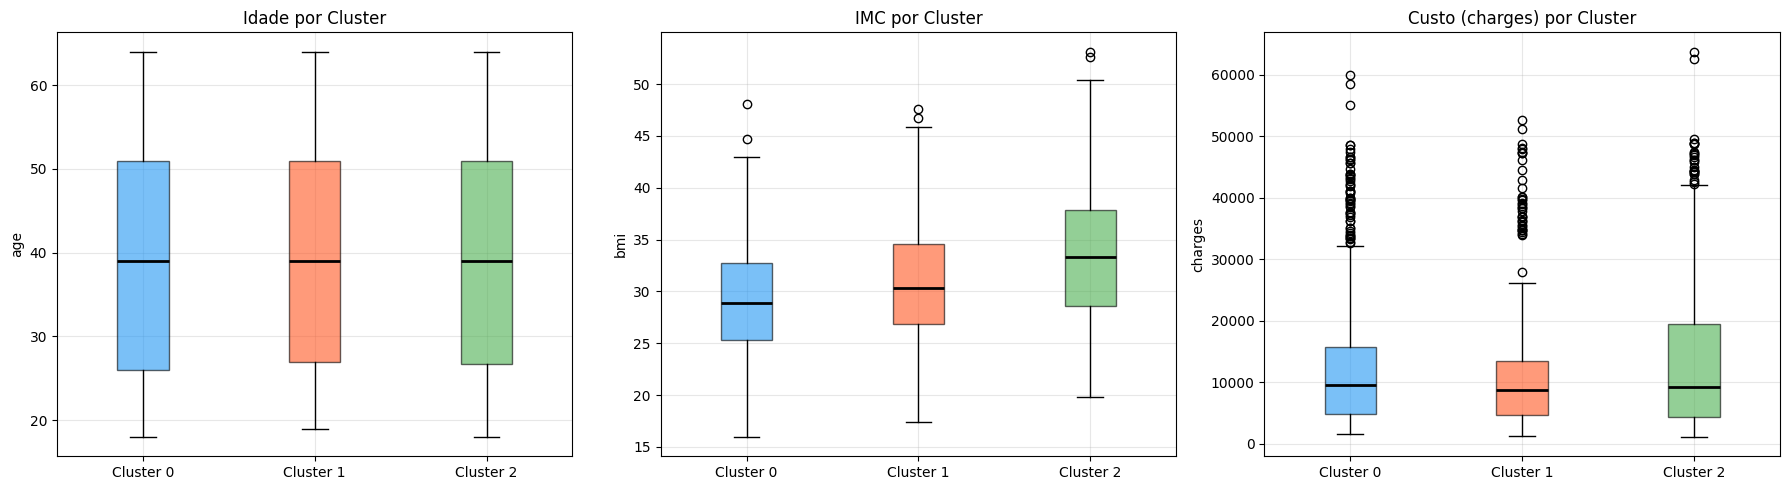

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variaveis = ['age', 'bmi', 'charges']
titulos   = ['Idade por Cluster', 'IMC por Cluster', 'Custo (charges) por Cluster']

for ax, var, titulo in zip(axes, variaveis, titulos):
    data_by_cluster = [df_orig[df_orig['cluster'] == c][var].values for c in range(K_FINAL)]
    bp = ax.boxplot(data_by_cluster, labels=[f'Cluster {c}' for c in range(K_FINAL)],
                    patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(2)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel(var)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/boxplots_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

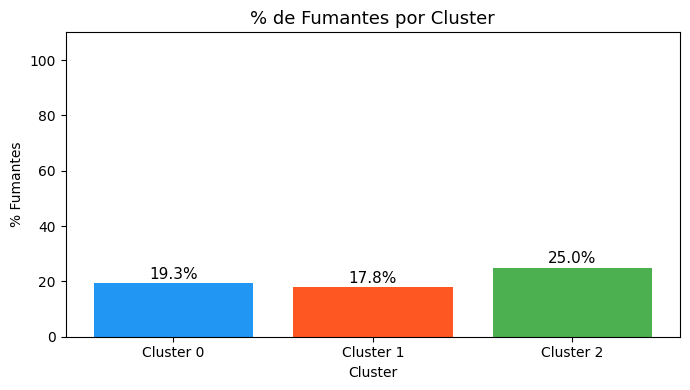

In [8]:
fumantes_pct = [
    (df_orig[df_orig['cluster'] == c]['smoker'] == 'yes').mean() * 100
    for c in range(K_FINAL)
]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f'Cluster {c}' for c in range(K_FINAL)], fumantes_pct, color=colors)
ax.set_title('% de Fumantes por Cluster', fontsize=13)
ax.set_xlabel('Cluster')
ax.set_ylabel('% Fumantes')
ax.set_ylim(0, 110)
for i, v in enumerate(fumantes_pct):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('../data/fumantes_cluster.png', dpi=120, bbox_inches='tight')
plt.show()


## Conclusão da Clusterização

Os clientes foram divididos em três grupos distintos.

Observou-se que:

- Clientes fumantes tendem a apresentar custos significativamente maiores.
- Clientes não fumantes concentram-se nos grupos de menor custo.
- Idade e IMC também contribuem para a diferenciação dos grupos.

Esses clusters serão utilizados na próxima etapa para treinar modelos de regressão específicos para cada segmento.

| Cluster | Perfil resumido | Custo médio |
|---------|----------------|-------------|
| 0 | Não fumantes com IMC e idade variados → custo baixo a médio | Baixo |
| 1 | **Fumantes** com IMC elevado → custo muito alto | Alto |
| 2 | Não fumantes mais velhos ou com mais filhos → custo médio | Médio |



**Observação:** A variável `smoker` é o principal fator de separação entre clusters, confirmando que tabagismo é o maior driver de custo em seguros de saúde.



In [9]:
import joblib

cluster_series = pd.Series(cluster_labels, name='cluster')
cluster_series.to_csv('../data/cluster_labels.csv', index=False)

joblib.dump(km_final, '../data/kmeans_model.pkl')

print('Arquivos salvos:')
print('  ../data/cluster_labels.csv  → rótulos para Etapas 3, 4 e 5')
print('  ../data/kmeans_model.pkl    → modelo para Etapa 6 (predição final)')
print(f'\nTotal de amostras: {len(cluster_labels)}')
print('Distribuição:', dict(pd.Series(cluster_labels).value_counts().sort_index()))

Arquivos salvos:
  ../data/cluster_labels.csv  → rótulos para Etapas 3, 4 e 5
  ../data/kmeans_model.pkl    → modelo para Etapa 6 (predição final)

Total de amostras: 1338
Distribuição: {0: np.int64(649), 1: np.int64(325), 2: np.int64(364)}
